# Student Performance Analysis

Author: Ayisha Mariyam  
Project Type: Education Data Analysis  
Tools Used: Python, Pandas, Matplotlib, Seaborn

---

## Project Objective

The purpose of this project is to analyze student academic performance using exam scores.

The analysis focuses on:

• Understanding performance trends in math, reading, and writing  
• Identifying factors influencing student scores  
• Examining the impact of test preparation courses  
• Understanding the influence of parental education level  

This analysis helps educators and institutions improve learning strategies and academic outcomes.

In [2]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("pastel")

print("Libraries imported successfully")

Libraries imported successfully


## Load Dataset

The dataset contains student exam scores along with demographic and preparation information.

In [3]:
df = pd.read_csv(r"E:\VS CODE\The Developer's Arena Internship 6 months\Month 2\Datasets\students_performance.csv")

print("Dataset loaded successfully")

Dataset loaded successfully


## Dataset Preview

Display the first five rows of the dataset.

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Dataset Shape

This shows the number of rows and columns in the dataset.

In [5]:
df.shape

(1000, 8)

## Dataset Information

This section displays:

• Column names  
• Data types  
• Non-null values

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


## Statistical Summary

This provides statistical metrics for exam scores including:

• Mean  
• Minimum  
• Maximum  
• Standard deviation

In [7]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## Data Quality Checks

Before performing analysis we check:

• Missing values  
• Duplicate rows

In [8]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

## Feature Engineering

We create a new feature called **Average Score** to measure overall student performance.

In [10]:
df['average_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


## Score Distribution

We visualize the distribution of scores across subjects.

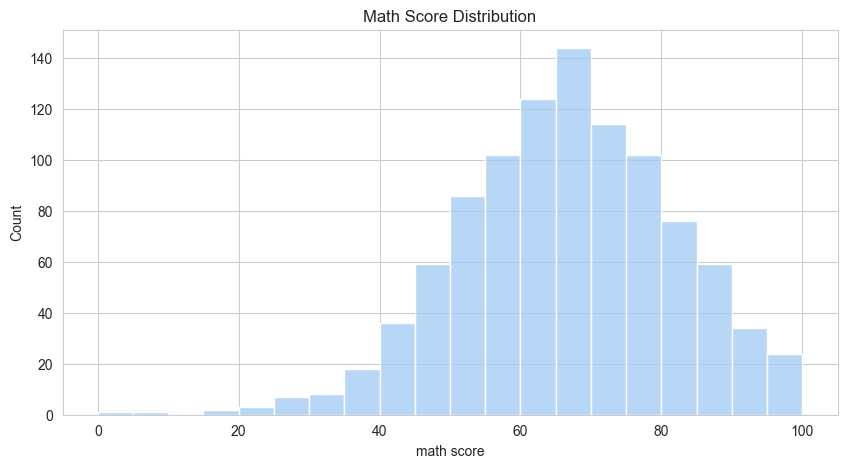

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(df['math score'], bins=20)

plt.title("Math Score Distribution")

plt.show()

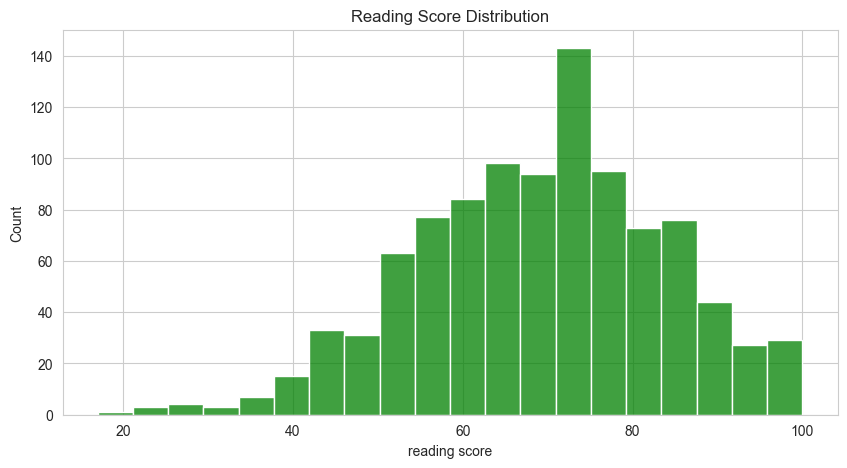

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(df['reading score'], bins=20, color='green')

plt.title("Reading Score Distribution")

plt.show()

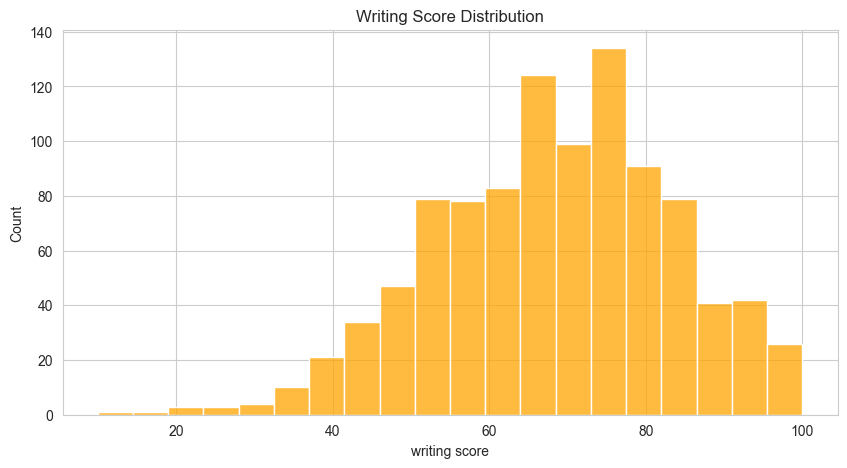

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(df['writing score'], bins=20, color='orange')

plt.title("Writing Score Distribution")

plt.show()

## Gender Performance Comparison

This analysis compares academic performance between male and female students.

In [18]:
gender_scores = df.groupby('gender')[['math score','reading score','writing score']].mean()

gender_scores

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


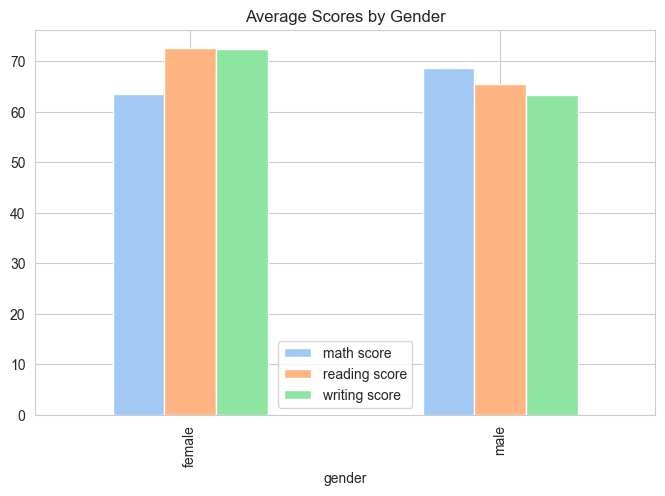

In [19]:
gender_scores.plot(kind='bar', figsize=(8,5))

plt.title("Average Scores by Gender")

plt.show()

## Impact of Test Preparation Course

In [20]:
prep_scores = df.groupby('test preparation course')[['math score','reading score','writing score']].mean()

prep_scores

,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


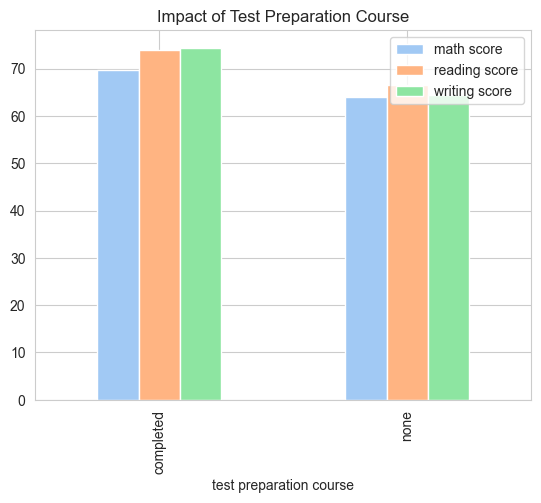

In [21]:
prep_scores.plot(kind='bar')

plt.title("Impact of Test Preparation Course")

plt.show()

## Parental Education Impact

This analysis examines whether parental education level affects student performance.

In [22]:
parent_scores = df.groupby('parental level of education')['average_score'].mean().sort_values()

parent_scores

parental level of education
high school           63.096939
some high school      65.108007
some college          68.476401
associate's degree    69.569069
bachelor's degree     71.923729
master's degree       73.598870
Name: average_score, dtype: float64

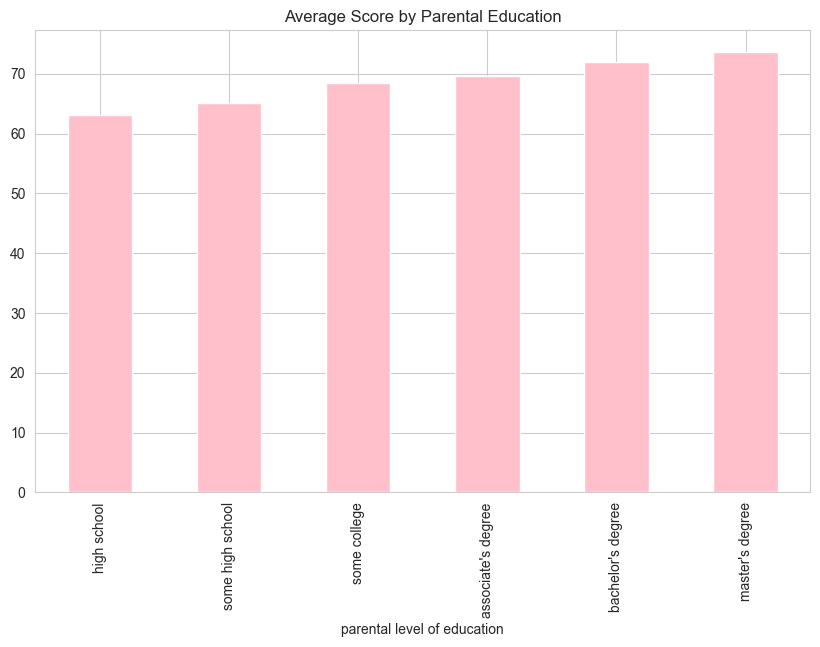

In [25]:
plt.figure(figsize=(10,6))

parent_scores.plot(kind='bar',color="pink")

plt.title("Average Score by Parental Education")

plt.show()

## Correlation Analysis

Correlation analysis helps identify relationships between exam scores.

In [26]:
corr = df[['math score','reading score','writing score','average_score']].corr()

corr

,math score,reading score,writing score,average_score
math score,1.000000,0.817580,0.802642,0.918746
reading score,0.817580,1.000000,0.954598,0.970331
writing score,0.802642,0.954598,1.000000,0.965667
average_score,0.918746,0.970331,0.965667,1.000000


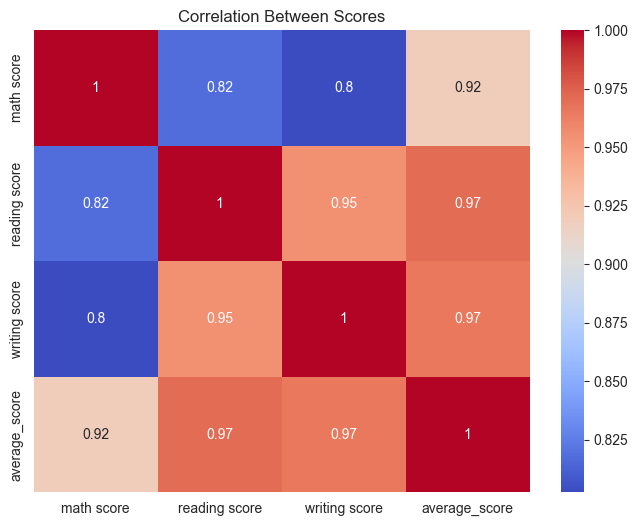

In [29]:
plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Between Scores")

plt.show()

# Key Insights

1. Students who completed the test preparation course generally achieved higher scores.
2. Reading and writing scores show a strong positive correlation.
3. Students with parents having higher education levels tend to perform better.
4. Female students often perform slightly better in reading and writing.
5. Overall student performance varies significantly across subjects.

# Business / Educational Recommendations

Based on the analysis:

• Encourage more students to enroll in test preparation programs  
• Provide additional support for students struggling in mathematics  
• Develop targeted interventions for low-performing groups  
• Encourage parental involvement in student learning  
• Implement personalized learning strategies based on performance patterns

# Conclusion

This project demonstrates how educational data analysis can help institutions understand student performance patterns.

Using Python and data visualization techniques, we analyzed multiple factors influencing exam scores. The insights generated can help educators design better teaching strategies and improve overall student success.